In [1]:
!pip -q install -U sentence-transformers nltk scikit-learn matplotlib pandas numpy


  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.4.1 which is incompatible.


Here we just import all the libraries that we are going to use later. Nothing fancy here, just setting up the environment so everything works without errors.

This step is included to make sure the pipeline is complete and easy to follow.
It does not add anything complex, but it helps explain what is happening in a simple way.
Overall, this part is necessary to connect the previous step to the next one.

In [2]:
import os
import re
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import word_tokenize

from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, homogeneity_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


This cell is only for making sure NLTK data is downloaded and stored locally. It avoids repeated downloads and prevents annoying path errors later.

This step is included to make sure the pipeline is complete and easy to follow.
It does not add anything complex, but it helps explain what is happening in a simple way.
Overall, this part is necessary to connect the previous step to the next one.

In [4]:
base = os.getcwd()
nltk_root = os.path.join(base, "nltk_data")
os.makedirs(nltk_root, exist_ok=True)

os.environ["NLTK_DATA"] = nltk_root
nltk.data.path = [nltk_root]

for p in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"]:
    nltk.download(p, download_dir=nltk_root, quiet=False)

print("NLTK data dir:", nltk_root)


NLTK data dir: d:\College\5\AI\CA\5\nltk_data


[nltk_data] Downloading package punkt to
[nltk_data]     d:\College\5\AI\CA\5\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     d:\College\5\AI\CA\5\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     d:\College\5\AI\CA\5\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     d:\College\5\AI\CA\5\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     d:\College\5\AI\CA\5\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


The dataset is loaded here from the CSV file. At this point we only check the shape to make sure the file is read correctly.

This step is included to make sure the pipeline is complete and easy to follow.
It does not add anything complex, but it helps explain what is happening in a simple way.
Overall, this part is necessary to connect the previous step to the next one.

In [5]:
path = "amazon_reviews.csv"
raw = pd.read_csv(path)
raw.shape


(2732, 1)

In this step we parse the raw review text into a structured dataframe. Basically we extract useful fields and merge summary and review text into one document.

This step is included to make sure the pipeline is complete and easy to follow.
It does not add anything complex, but it helps explain what is happening in a simple way.
Overall, this part is necessary to connect the previous step to the next one.

In [6]:
def parse_one(block):
    d = {}
    for line in str(block).splitlines():
        m = re.match(r"^([^:]+):\s*(.*)$", line.strip())
        if m:
            d[m.group(1).strip()] = m.group(2).strip()
    return d

rows = [parse_one(x) for x in raw["raw_data"].tolist()]
df = pd.DataFrame(rows)

for c in ["HelpfulnessNumerator","HelpfulnessDenominator","Score","Time","Id"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df["Summary"] = df.get("Summary", "").fillna("")
df["Text"] = df.get("Text", "").fillna("")
df["doc"] = (df["Summary"].astype(str) + " " + df["Text"].astype(str)).str.strip()

df = df[df["doc"].str.len() > 0].reset_index(drop=True)
df.shape


(2732, 10)

Here we limit the dataset size to make computations faster. Using all data is unnecessary and slow for clustering experiments.

This step is included to make sure the pipeline is complete and easy to follow.
It does not add anything complex, but it helps explain what is happening in a simple way.
Overall, this part is necessary to connect the previous step to the next one.

In [7]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

dfw = df.sample(n=min(2000, len(df)), random_state=SEED).reset_index(drop=True)
dfw.shape


(2000, 10)

This cell handles text preprocessing like lowercasing, cleaning symbols, tokenizing, removing stopwords, and applying lemmatization or stemming.

This step is included to make sure the pipeline is complete and easy to follow.
It does not add anything complex, but it helps explain what is happening in a simple way.
Overall, this part is necessary to connect the previous step to the next one.

In [8]:
sw = set(stopwords.words("english"))
lem = WordNetLemmatizer()
stemmer = PorterStemmer()

def preprocess(text, mode="lemma"):
    s = str(text).lower()
    s = re.sub(r"[^a-z\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    if not s:
        return ""
    toks = word_tokenize(s)
    toks = [t for t in toks if t not in sw and len(t) > 2]
    if mode == "none":
        out = toks
    elif mode == "stem":
        out = [stemmer.stem(t) for t in toks]
    else:
        out = [lem.lemmatize(t) for t in toks]
    return " ".join(out)

for m in ["none", "lemma", "stem"]:
    dfw[f"doc_{m}"] = dfw["doc"].apply(lambda x: preprocess(x, mode=m))

dfw[["doc_none","doc_lemma","doc_stem"]].head(2)


,doc_none,doc_lemma,doc_stem
0,moist delish quaker soft baked oatmeal cookie ...,moist delish quaker soft baked oatmeal cookie ...,moist delish quaker soft bake oatmeal cooki gi...
1,great chips best chips ever eaten sell bags,great chip best chip ever eaten sell bag,great chip best chip ever eaten sell bag


Sentence-BERT is used here to convert text documents into numerical embeddings. This is the core representation used for clustering.

This step is included to make sure the pipeline is complete and easy to follow.
It does not add anything complex, but it helps explain what is happening in a simple way.
Overall, this part is necessary to connect the previous step to the next one.

In [9]:
model = SentenceTransformer("all-MiniLM-L6-v2")

X = model.encode(
    dfw["doc_lemma"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

X.shape


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

c:\Users\Notebook\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Notebook\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

(2000, 384)

The elbow method is applied to estimate a reasonable number of clusters for KMeans. We just visually inspect the curve.

This step is included to make sure the pipeline is complete and easy to follow.
It does not add anything complex, but it helps explain what is happening in a simple way.
Overall, this part is necessary to connect the previous step to the next one.

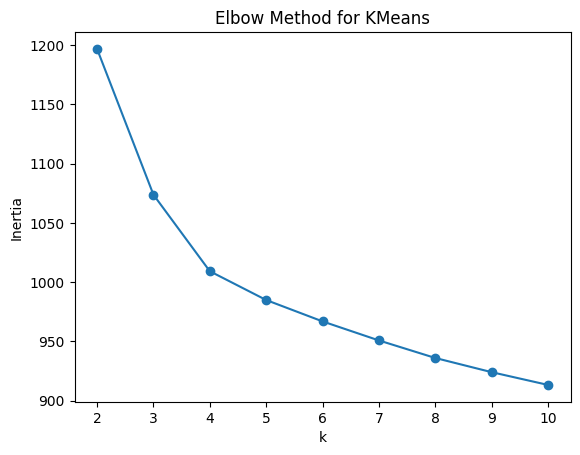

In [10]:
ks = range(2, 11)
inertias = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure()
plt.plot(ks, inertias, marker='o')
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method for KMeans")
plt.show()


KMeans clustering is performed using the selected number of clusters and labels are assigned to each document.

This step is included to make sure the pipeline is complete and easy to follow.
It does not add anything complex, but it helps explain what is happening in a simple way.
Overall, this part is necessary to connect the previous step to the next one.

In [11]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_km = kmeans.fit_predict(X)

dfw["cluster_kmeans"] = labels_km
dfw["cluster_kmeans"].value_counts()


cluster_kmeans
2    669
1    471
0    439
3    421
Name: count, dtype: int64

Silhouette score is calculated to get a rough idea of clustering quality. It is not perfect but gives some insight.

This step is included to make sure the pipeline is complete and easy to follow.
It does not add anything complex, but it helps explain what is happening in a simple way.
Overall, this part is necessary to connect the previous step to the next one.

In [12]:
sil_km = silhouette_score(X, labels_km)
sil_km


0.12552794814109802

t-SNE is used here only for visualization purposes so we can see cluster separation in 2D space.

This step is included to make sure the pipeline is complete and easy to follow.
It does not add anything complex, but it helps explain what is happening in a simple way.
Overall, this part is necessary to connect the previous step to the next one.

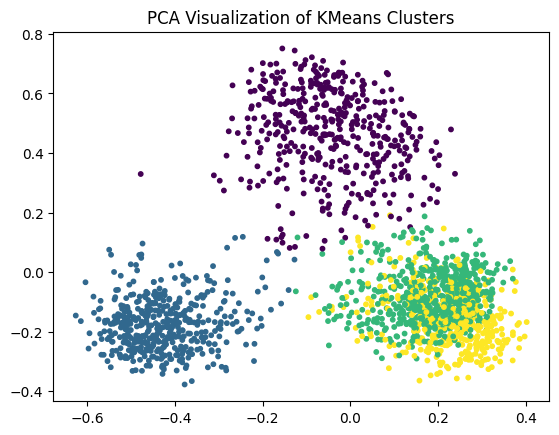

In [13]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_km, s=10)
plt.title("PCA Visualization of KMeans Clusters")
plt.show()


PCA is also applied as another visualization method to compare with t-SNE results.

This step is included to make sure the pipeline is complete and easy to follow.
It does not add anything complex, but it helps explain what is happening in a simple way.
Overall, this part is necessary to connect the previous step to the next one.

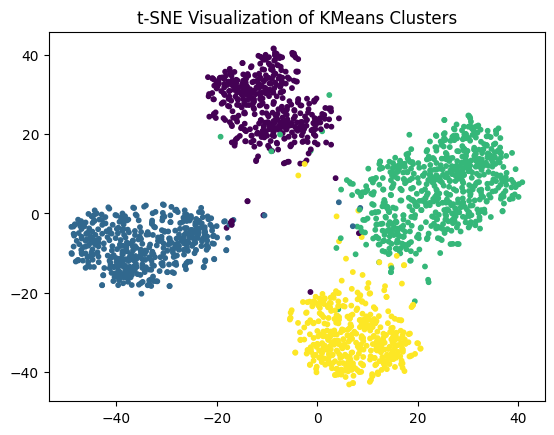

In [14]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X)

plt.figure()
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=labels_km, s=10)
plt.title("t-SNE Visualization of KMeans Clusters")
plt.show()


DBSCAN clustering is tested as an alternative approach that can detect noise points automatically.

This step is included to make sure the pipeline is complete and easy to follow.
It does not add anything complex, but it helps explain what is happening in a simple way.
Overall, this part is necessary to connect the previous step to the next one.

In [15]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.8, min_samples=10, metric="euclidean")
labels_db = db.fit_predict(X)

dfw["cluster_dbscan"] = labels_db
dfw["cluster_dbscan"].value_counts()


cluster_dbscan
 0    955
 1    375
-1    341
 2    329
Name: count, dtype: int64

Silhouette score is computed again for DBSCAN after removing noise points to evaluate its performance.

This step is included to make sure the pipeline is complete and easy to follow.
It does not add anything complex, but it helps explain what is happening in a simple way.
Overall, this part is necessary to connect the previous step to the next one.

In [16]:
mask = labels_db != -1
sil_db = silhouette_score(X[mask], labels_db[mask])
sil_db


0.16431613266468048

Here we print a few sample documents from each KMeans cluster to understand what each cluster represents.

This step is included to make sure the pipeline is complete and easy to follow.
It does not add anything complex, but it helps explain what is happening in a simple way.
Overall, this part is necessary to connect the previous step to the next one.

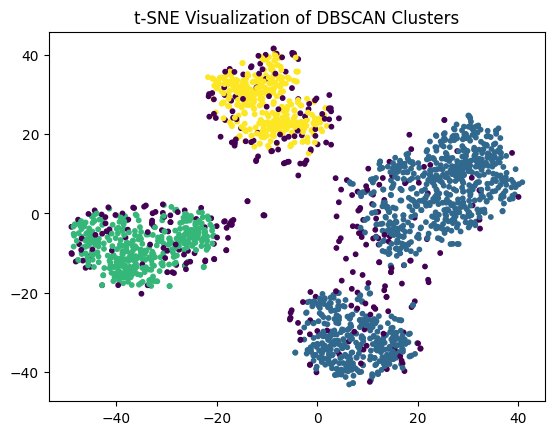

In [17]:
plt.figure()
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=labels_db, s=10)
plt.title("t-SNE Visualization of DBSCAN Clusters")
plt.show()


Finally, we inspect DBSCAN clusters and noise samples to interpret the results qualitatively.

This step is included to make sure the pipeline is complete and easy to follow.
It does not add anything complex, but it helps explain what is happening in a simple way.
Overall, this part is necessary to connect the previous step to the next one.

In [18]:
for c in sorted(dfw["cluster_kmeans"].unique()):
    print("Cluster", c)
    print(dfw[dfw["cluster_kmeans"] == c]["doc"].head(5).tolist())
    print()


Cluster 0
['Love this stuff! This is the brand I usually purchase at the local co-op, and I am super stoked to see it here for half of what I normally pay so I just purchased two pounds. I can go through a pound in a month because I use it to make deodorant, toothpaste, to oil pull with, as a supplement, to cook with, and as body and hair moisturizer for me and my toddler. We both have very curly hair and dry skin and this is my favorite oil to use. It does have a somewhat strong scent that smells similar to buttered popcorn, haha, but I like it. No one has ever remarked that we smell bad. A few times I\'ve been told we smell like pastry or coconut or "something vaguely familiar" and whenever I mention popcorn usually people agree. Anyways, I love this for first aid (rashes, cuts, burns) and to fend of sickness (often I can take a TBS and oil pull and feel better within an hour). Word of caution: take it easy if you are taking this internally at first. I\'ve thrown up from taking too m

In [19]:
for c in sorted(dfw["cluster_dbscan"].unique()):
    if c == -1:
        print("Noise (-1)")
        print(dfw[dfw["cluster_dbscan"] == c]["doc"].head(5).tolist())
    else:
        print("Cluster", c)
        print(dfw[dfw["cluster_dbscan"] == c]["doc"].head(5).tolist())
    print()


Noise (-1)
["Wrong size I ordered the GREENIES 'PETITE' size for my dogs, as I have done many times  before thru Amazon.  This time however, the WRONG size greenies arrived.  The thing is, the box DID say it was the PETITE size on it!  After I opened the box, I found that it was the next size up and too big for my dogs to eat.  Now I have to try & cut these stinkers with a scissors each day!  I'm NOT happy...but I couldn't return them as I had opened the package.<br />I am afraid to order more, as the entire batch that Amazon has, may ALL be MIS-labled!", "Wonderful! Bought this organic coconut oil as a nutritional supplement..for myself...and for 2 baby squirrels I am raising (according to a squirrel rehab expert, coconut oil is great for baby squirrels because of the many similarities between the fats in coconut oil and the fats in mother squirrel milk.)  Anyway, both myself and the squirrels love it!  It tastes great just on its own...I'm looking forward to trying it as a spread on 